# OPF


In [1]:
import sys
import os
import torch
from torch.autograd import Function
torch.set_default_dtype(torch.float64)
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import scipy
from scipy.sparse import csr_matrix
sys.path.insert(1, os.path.join(sys.path[0], os.pardir, os.pardir))
import hashlib
from copy import deepcopy
from pypower.api import case30
from pypower.api import opf, makeYbus, makeB
from pypower import idx_bus, idx_gen, ppoption
import time
import argparse
import pyomo.environ as pyo
import numpy as np
import torch
import time
import torch.nn as nn
import matplotlib.pyplot as plt
import scipy.io as spio
from pypower.api import case118
current_dir = os.getcwd()
dir = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
sys.path.append(dir) # Add the parent directory to Python's search path
results_dir = os.path.join(current_dir, "examples/results")
from Opt_Layer.pyomolayer import PyomoOptLayer

In [2]:
data_dir = "data_OPF"
case_dir = os.path.join(data_dir)
save_dir = os.path.join("results")

def str_to_bool(value):
    if isinstance(value, bool):
        return value
    if value.lower() in {'false', 'f', '0', 'no', 'n'}:
        return False
    elif value.lower() in {'true', 't', '1', 'yes', 'y'}:
        return True
    raise ValueError('{value} is not a valid boolean value')

def my_hash(string):
    return hashlib.sha1(bytes(string, 'utf-8')).hexdigest()

In [3]:
parser = argparse.ArgumentParser(description='DC3')
parser.add_argument('--probType', type=str, default='acopf57', help='problem type')
parser.add_argument('--epochs', type=int, default=100,
    help='number of neural network epochs')
parser.add_argument('--batchSize', type=int, default=32,
    help='training batch size')
parser.add_argument('--lr', type=float, default=0.0005,
    help='neural network learning rate')
parser.add_argument('--hiddenSize', type=int, default=50,
    help='hidden layer size for neural network')
parser.add_argument('--saveAllStats', type=str_to_bool, default=False,
    help='whether to save all stats, or just those from latest epoch')
parser.add_argument('--resultsSaveFreq', type=int, default=10,
    help='how frequently (in terms of number of epochs) to save stats to file')

args = parser.parse_args([])
args = vars(args) # change to dictionary
print(args)

{'probType': 'acopf57', 'epochs': 100, 'batchSize': 32, 'lr': 0.0005, 'hiddenSize': 50, 'saveAllStats': False, 'resultsSaveFreq': 10}


In [4]:
class ACOPFProblem:
    """
        minimize_{p_g, q_g, vmag, vang} p_g^T A p_g + b p_g + c
        s.t.                  p_g min   <= p_g  <= p_g max
                              q_g min   <= q_g  <= q_g max
                              vmag min  <= vmag <= vmag max
                              vang_slack = \theta_slack   # voltage angle
                              (p_g - p_d) + (q_g - q_d)i = diag(vmag e^{i*vang}) conj(Y) (vmag e^{-i*vang})
    """

    def __init__(self, filename, ppc, num, valid_frac=0.1, test_frac=0.2):

        self.nbus = int(filename.split('_')[-1][4:-4])

        ## Define useful power network quantities and indices
        data = spio.loadmat(filename)

        self.ppc = ppc

        self.genbase = ppc['gen'][:, idx_gen.MBASE]
        self.baseMVA = ppc['baseMVA'] * 1.0
        # self.connect_matrix = ppc['connect_matrix']

        self.slack = np.where(ppc['bus'][:, idx_bus.BUS_TYPE] == 3)[0]
        self.pv = np.where(ppc['bus'][:, idx_bus.BUS_TYPE] == 2)[0]
        self.spv = np.concatenate([self.slack, self.pv])
        self.spv.sort()
        self.pq = np.setdiff1d(range(self.nbus), self.spv)
        self.nonslack_idxes = np.sort(np.concatenate([self.pq, self.pv]))
        self.allbus_idxes = np.arange(self.nbus)

        # indices within gens
        self.slack_ = np.array([np.where(x == self.spv)[0][0] for x in self.slack])
        self.pv_ = np.array([np.where(x == self.spv)[0][0] for x in self.pv])
        self.pv_nonslack_idxes = np.array([np.where(x == self.nonslack_idxes)[0][0] for x in self.pv])

        self.ng = ppc['gen'].shape[0]
        self.allgen_idxes = np.arange(self.ng)
        self.nslack = len(self.slack)
        self.npv = len(self.pv)
        self.nbr = ppc['branch'].shape[0]

        self.quad_costs = torch.tensor(ppc['gencost'][:,4], dtype=torch.get_default_dtype())
        self.lin_costs  = torch.tensor(ppc['gencost'][:,5], dtype=torch.get_default_dtype())
        self.const_cost = ppc['gencost'][:,6].sum()

        self.pmax = torch.tensor(ppc['gen'][:,idx_gen.PMAX] / self.genbase, dtype=torch.get_default_dtype())
        self.pmin = torch.tensor(ppc['gen'][:,idx_gen.PMIN] / self.genbase, dtype=torch.get_default_dtype())
        self.qmax = torch.tensor(ppc['gen'][:,idx_gen.QMAX] / self.genbase, dtype=torch.get_default_dtype())
        self.qmin = torch.tensor(ppc['gen'][:,idx_gen.QMIN] / self.genbase, dtype=torch.get_default_dtype())
        self.vmax = torch.tensor(ppc['bus'][:,idx_bus.VMAX], dtype=torch.get_default_dtype())
        self.vmin = torch.tensor(ppc['bus'][:,idx_bus.VMIN], dtype=torch.get_default_dtype())
        self.slackva = torch.tensor([np.deg2rad(ppc['bus'][self.slack, idx_bus.VA])], dtype=torch.get_default_dtype()).squeeze(-1)
        self.bfmax = torch.tensor((ppc['branch'][:,5] / self.baseMVA)**2, dtype=torch.get_default_dtype())

        ppc2 = deepcopy(ppc)
        ppc2['bus'][:, 0] -= 1
        ppc2['branch'][:, [0, 1]] -= 1
        Ybus, Yf, _ = makeYbus(self.baseMVA, ppc2['bus'], ppc2['branch'])
        Ybus = Ybus.todense()
        Yfbus = Yf.todense()
        self.Ybusr = torch.tensor(np.real(Ybus), dtype=torch.get_default_dtype())
        self.Ybusi = torch.tensor(np.imag(Ybus), dtype=torch.get_default_dtype())
        self.Yfbusr = torch.tensor(np.real(Yfbus), dtype=torch.get_default_dtype())
        self.Yfbusi = torch.tensor(np.imag(Yfbus), dtype=torch.get_default_dtype())
        self.line_susceptance = ppc2['branch'][:,4]

        Bp, Bpp = makeB(self.baseMVA, ppc2['bus'], ppc2['branch'], 2)
        Bp = Bp.todense()
        Bpp = Bpp.todense()
        Bp_reduced = Bp[np.concatenate([self.pv, self.pq]),:][:,np.concatenate([self.pv, self.pq])]
        Bpp_reduced = Bpp[np.concatenate([self.pq]),:][:,np.concatenate([self.pq])]
        self.Bp = torch.inverse(torch.tensor(Bp_reduced, dtype=torch.get_default_dtype()))
        self.Bpp = torch.inverse(torch.tensor(Bpp_reduced, dtype=torch.get_default_dtype()))

        Bp_reduced1 = Bp[self.nonslack_idxes, :][:, self.nonslack_idxes]
        Bpp_reduced1 = Bpp[self.nonslack_idxes, :][:, self.nonslack_idxes]
        self.Bp1 = torch.inverse(torch.tensor(Bp_reduced1, dtype=torch.get_default_dtype()))
        self.Bpp1 = torch.inverse(torch.tensor(Bpp_reduced1, dtype=torch.get_default_dtype()))

        self.F_BUS = ppc2['branch'][:, 0].astype(int)
        self.T_BUS = ppc2['branch'][:, 1].astype(int)

        ppc3 = deepcopy(ppc2)
        ppc3['branch'][:, 4] = 0
        _, Yf_nosus, _ = makeYbus(self.baseMVA, ppc3['bus'], ppc3['branch'])
        Yfbus_nosus = Yf_nosus.todense()
        self.Yfbusr_nosus = torch.tensor(np.real(Yfbus_nosus), dtype=torch.get_default_dtype())
        self.Yfbusi_nosus = torch.tensor(np.imag(Yfbus_nosus), dtype=torch.get_default_dtype())

        self.Cf = torch.tensor(np.transpose(csr_matrix((np.ones(self.nbr), (range(self.nbr), self.F_BUS)), (self.nbr, self.nbus)).todense()), dtype=torch.get_default_dtype())
        self.Ct = torch.tensor(np.transpose(csr_matrix((np.ones(self.nbr), (range(self.nbr), self.T_BUS)), (self.nbr, self.nbus)).todense()), dtype=torch.get_default_dtype())
        self.adj = self.Cf - self.Ct
        ## Define optimization problem input and output variables
        demand = data['Dem'].T / self.baseMVA
        gen =  data['Gen'].T / self.genbase
        voltage = data['Vol'].T
        # branch_flow = branch_flow / self.baseMVA / self.baseMVA

        X = np.concatenate([np.real(demand), np.imag(demand)], axis=1)[:num,:]
        Y = np.concatenate([np.real(gen), np.imag(gen), np.abs(voltage), np.angle(voltage)], axis=1)[:num,:]
        feas_mask =  ~np.isnan(Y).any(axis=1)

        self._X = torch.tensor(X[feas_mask], dtype=torch.get_default_dtype())
        self._Y = torch.tensor(Y[feas_mask], dtype=torch.get_default_dtype())
        self._xdim = X.shape[1]
        self._ydim = Y.shape[1]
        self._num = feas_mask.sum()

        self._neq = 2*self.nbus
        self._nineq = 4*self.ng + 2*self.nbus
        self._nknowns = self.nslack

        # indices of useful quantities in full solution
        self.pg_start_yidx = 0
        self.qg_start_yidx = self.ng
        self.vm_start_yidx = 2*self.ng
        self.va_start_yidx = 2*self.ng + self.nbus
        self.bf_start_yidx = 2*self.ng + 2*self.nbus
        ## Define train/valid/test split
        self._valid_frac = valid_frac
        self._test_frac = test_frac

        ## Define variables and indices for "partial completion" neural network

        # pg (non-slack) and |v|_g (including slack)
        self._partial_vars = np.concatenate([self.pg_start_yidx + self.pv_, self.vm_start_yidx + self.spv, self.va_start_yidx + self.slack])
        self._partial_vars_bf = np.concatenate([self.spv, self.nbus + self.slack])
        self._other_vars = np.setdiff1d(np.arange(self.ydim), self._partial_vars)
        self._partial_unknown_vars = np.concatenate([self.pg_start_yidx + self.pv_, self.vm_start_yidx + self.spv])

        # initial values for solver
        self.vm_init = ppc['bus'][:, idx_bus.VM]
        self.va_init = np.deg2rad(ppc['bus'][:, idx_bus.VA])
        self.pg_init = ppc['gen'][:, idx_gen.PG] / self.genbase
        self.qg_init = ppc['gen'][:, idx_gen.QG] / self.genbase

        # voltage angle at slack buses (known)
        self.slack_va = self.va_init[self.slack]

        # indices of useful quantities in partial solution
        self.pg_pv_zidx = np.arange(self.npv)
        self.vm_spv_zidx = np.arange(self.npv, 2*self.npv + self.nslack)

        # indices of useful quantities in partial solution for post processing
        self.pg_zidx = np.arange(self.npv)
        self.qg_zidx = np.arange(self.npv, self.npv+self.npv)

        # useful indices for equality constraints
        self.pflow_start_eqidx = 0
        self.qflow_start_eqidx = self.nbus


        ### For Pytorch
        self._device = None

    @property
    def X(self):
        return self._X

    @property
    def Y(self):
        return self._Y

    @property
    def partial_vars(self):
        return self._partial_vars

    @property
    def partial_vars_bf(self):
        return self._partial_vars_bf

    @property
    def other_vars(self):
        return self._other_vars

    @property
    def partial_unknown_vars(self):
        return self._partial_unknown_vars

    @property
    def xdim(self):
        return self._xdim

    @property
    def ydim(self):
        return self._ydim

    @property
    def num(self):
        return self._num

    @property
    def neq(self):
        return self._neq

    @property
    def nineq(self):
        return self._nineq

    @property
    def nknowns(self):
        return self._nknowns

    @property
    def valid_frac(self):
        return self._valid_frac

    @property
    def test_frac(self):
        return self._test_frac

    @property
    def train_frac(self):
        return 1 - self.valid_frac - self.test_frac

    @property
    def trainX(self):
        return self.X[:int(self.num * self.train_frac)]

    @property
    def validX(self):
        return self.X[int(self.num * self.train_frac):int(self.num * (self.train_frac + self.valid_frac))]

    @property
    def testX(self):
        return self.X[int(self.num * (self.train_frac + self.valid_frac)):]

    @property
    def trainY(self):
        return self.Y[:int(self.num*self.train_frac)]

    @property
    def validY(self):
        return self.Y[int(self.num*self.train_frac):int(self.num*(self.train_frac + self.valid_frac))]

    @property
    def testY(self):
        return self.Y[int(self.num*(self.train_frac + self.valid_frac)):]

    @property
    def device(self):
        return self._device

    def trainX_fake(self, X, num_fake):
        return X[:int(num_fake*self.train_frac)]

    def validX_fake(self, X, num_fake):
        return X[int(num_fake*self.train_frac):int(num_fake*(self.train_frac + self.valid_frac))]

    def testX_fake(self, X, num_fake):
        return X[int(num_fake*(self.train_frac + self.valid_frac)):]

    def trainY_fake(self, Y, num_fake):
        return Y[:int(num_fake*self.train_frac)]

    def validY_fake(self, Y, num_fake):
        return Y[int(num_fake*self.train_frac):int(num_fake*(self.train_frac + self.valid_frac))]

    def testY_fake(self, Y, num_fake):
        return Y[int(num_fake*(self.train_frac + self.valid_frac)):]


    def get_yvars(self, Y):
        pg = Y[:, :self.ng]
        qg = Y[:, self.ng:2*self.ng]
        vm = Y[:, 2*self.ng:2*self.ng+self.nbus]
        va = Y[:, 2*self.ng+self.nbus:2*self.ng+2*self.nbus]
        # bf = Y[:, 2*self.ng+2*self.nbus:]
        return pg, qg, vm, va

    def obj_fn(self, Y):
        pg, _, _, _  = self.get_yvars(Y)
        pg_mw = pg * torch.tensor(self.genbase).to(self.device)
        cost = (self.lin_costs * pg_mw).sum(axis=1) 
        return cost / (self.genbase.mean() ** 2)

    def eq_resid(self, X, Y):
        pg, qg, vm, va = self.get_yvars(Y)

        vr = vm*torch.cos(va)
        vi = vm*torch.sin(va)

        ## power balance equations
        tmp1 = vr@self.Ybusr - vi@self.Ybusi
        tmp2 = -vr@self.Ybusi - vi@self.Ybusr

        # real power
        pg_expand = torch.zeros(pg.shape[0], self.nbus, device=self.device)
        pg_expand[:, self.spv] = pg
        real_resid = (pg_expand - X[:, :self.nbus]) - (vr*tmp1 - vi*tmp2)

        # reactive power
        qg_expand = torch.zeros(qg.shape[0], self.nbus, device=self.device)
        qg_expand[:, self.spv] = qg
        react_resid = (qg_expand - X[:, self.nbus:]) - (vr*tmp2 + vi*tmp1)

        ## all residuals
        resids = torch.cat([
            real_resid,
            react_resid
        ], dim=1)

        return resids

    def eq_resid_bf(self, X, Y):
        _, _, vm, va, _ = self.get_yvars(Y)

        vr = vm*torch.cos(va)
        vi = vm*torch.sin(va)

        vfr = vr@self.Cf # 8 *41
        vfi = vi@self.Cf # 8 *41

        ## power balance equations
        tmp1 = vr@torch.transpose(self.Yfbusr,0,1) - vi@torch.transpose(self.Yfbusi,0,1) # batch_size * nbr
        tmp2 = -vr@torch.transpose(self.Yfbusi,0,1) - vi@torch.transpose(self.Yfbusr,0,1)

        # real power flow
        pf = (vfr*tmp1 - vfi*tmp2)

        # reactive power flow
        qf = (vfr*tmp2 + vfi*tmp1)

        return pf, qf

    def ineq_resid(self, X, Y):
        pg, qg, vm, va = self.get_yvars(Y)
        resids = torch.cat([
            pg - self.pmax,
            self.pmin - pg,
            qg - self.qmax,
            self.qmin - qg,
            vm - self.vmax,
            self.vmin - vm,
        ], dim=1)
        return resids

    def ineq_dist(self, X, Y):
        resids = self.ineq_resid(X, Y)
        return torch.clamp(resids, 0)

    def ineq_resid_imp(self, X, Y):
        _, _, vm, _, _ = self.get_yvars(Y)
        vm_pq = vm[:, self.pq]
        resids = torch.cat([
            vm_pq - self.vmax[self.pq],
            self.vmin[self.pq] - vm_pq,
        ], dim=1)
        return resids

    def ineq_dist_imp(self, X, Y):
        resids = self.ineq_resid_imp(X, Y)
        return torch.clamp(resids, 0)

    def ineq_resid_unimp(self, X, Y):
        pg, qg, _, _, bf = self.get_yvars(Y)
        pg_slack = pg[:, self.slack_]
        resids = torch.cat([
            pg_slack - self.pmax[self.slack_],
            self.pmin[self.slack_] - pg_slack,
            qg - self.qmax,
            self.qmin - qg,
            bf - self.bfmax[self.branch_nonbinding]
        ], dim=1)
        return resids

    def ineq_dist_unimp(self, X, Y):
        resids = self.ineq_resid_unimp(X, Y)
        return torch.clamp(resids, 0)

    def eq_grad(self, X, Y):
        eq_jac = self.eq_jac(Y)
        eq_resid = self.eq_resid(X,Y)
        return 2*eq_jac.transpose(1,2).bmm(eq_resid.unsqueeze(-1)).squeeze(-1)

    def ineq_grad(self, X, Y):
        ineq_jac = self.ineq_jac(Y)
        ineq_dist = self.ineq_dist(X, Y)
        return 2*ineq_jac.transpose(1,2).bmm(ineq_dist.unsqueeze(-1)).squeeze(-1)

    def eq_jac_pfqf(self, Y):

        _, _, vm, va = self.get_yvars(Y)

        dreal_dvm = torch.zeros(vm.shape[0], self.nbr*2, device=self.device)
        dreal_dva = torch.zeros(vm.shape[0], self.nbr, device=self.device)
        dreact_dvm = torch.zeros(vm.shape[0], self.nbr*2, device=self.device)
        dreact_dva = torch.zeros(vm.shape[0], self.nbr, device=self.device)
        Yfr = self.Yfbusr_nosus
        Yfi = self.Yfbusi_nosus
        i = 0
        for k in range (0, self.nbr*2, 2):
            from_bus = self.F_BUS[i]
            to_bus = self.T_BUS[i]
            # real power equations
            dreal_dvm[:, k] = -2*Yfr[i, from_bus]*vm[:, from_bus] \
            +vm[:, to_bus]*(Yfr[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]))
            dreal_dvm[:, k+1] = vm[:, from_bus]*(Yfr[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]))

            dreal_dva[:, i] = vm[:, from_bus] * vm[:, to_bus]*(-Yfr[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]))

            # reactive power equations
            dreact_dvm[:, k] = (self.line_susceptance[i] + 2*Yfi[i, from_bus]) *vm[:, from_bus] \
            +vm[:, to_bus]*(Yfr[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]) - Yfi[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]))
            dreact_dvm[:, k+1] = vm[:, from_bus]*(Yfr[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]) - Yfi[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]))

            dreact_dva[:, i] = vm[:, from_bus] * vm[:, to_bus]*(Yfr[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]))

            i = i + 1

        return torch.cat([dreal_dvm, dreact_dvm, dreal_dva, dreact_dva], dim=1)

    def eq_jac_bf_modi2(self, Y, Pf, Qf, eq_jac):

        from_index = np.arange(0, self.nbr*2, 2)
        to_index = np.arange(1, self.nbr*2, 2)

        dreal_dvm = eq_jac[:, :self.nbr*2]
        dreact_dvm = eq_jac[:, self.nbr*2:self.nbr*4]
        dreal_dva = eq_jac[:, self.nbr*4:self.nbr*5]
        dreact_dva = eq_jac[:, -self.nbr:]

        Sf_vmf = 2 * Pf * -dreal_dvm[:, from_index] + 2 * Qf * -dreact_dvm[:, from_index]
        Sf_vmt = 2 * Pf * -dreal_dvm[:, to_index] + 2 * Qf * -dreact_dvm[:, to_index]
        Sf_vaf = 2 * Pf * -dreal_dva + 2 * Qf * -dreact_dva

        return torch.cat([Sf_vmf, Sf_vmt, Sf_vaf], dim=1)

    def eq_jac(self, Y):
        _, _, vm, va = self.get_yvars(Y)

        # helper functions
        mdiag = lambda v1, v2: torch.diag_embed(v1).bmm(torch.diag_embed(v2))
        Ydiagv = lambda Y, v: Y.unsqueeze(0).expand(v.shape[0], *Y.shape).bmm(torch.diag_embed(v))
        dtm = lambda v, M: torch.diag_embed(v).bmm(M)

        # helper quantities
        cosva = torch.cos(va)
        sinva = torch.sin(va)
        vr = vm * torch.cos(va)
        vi = vm * torch.sin(va)
        Yr = self.Ybusr
        Yi = self.Ybusi
        YrvrYivi = vr@Yr - vi@Yi
        YivrYrvi = vr@Yi + vi@Yr

        # real power equations
        dreal_dpg = torch.zeros(self.nbus, self.ng, device=self.device) 
        dreal_dpg[self.spv, :] = torch.eye(self.ng, device=self.device)
        dreal_dvm = -mdiag(cosva, YrvrYivi) - dtm(vr, Ydiagv(Yr, cosva)-Ydiagv(Yi, sinva)) \
            -mdiag(sinva, YivrYrvi) - dtm(vi, Ydiagv(Yi, cosva)+Ydiagv(Yr, sinva))
        dreal_dva = -mdiag(-vi, YrvrYivi) - dtm(vr, Ydiagv(Yr, -vi)-Ydiagv(Yi, vr)) \
            -mdiag(vr, YivrYrvi) - dtm(vi, Ydiagv(Yi, -vi)+Ydiagv(Yr, vr))
        
        # reactive power equations
        dreact_dqg = torch.zeros(self.nbus, self.ng, device=self.device)
        dreact_dqg[self.spv, :] = torch.eye(self.ng, device=self.device)
        dreact_dvm = mdiag(cosva, YivrYrvi) + dtm(vr, Ydiagv(Yi, cosva)+Ydiagv(Yr, sinva)) \
            -mdiag(sinva, YrvrYivi) - dtm(vi, Ydiagv(Yr, cosva)-Ydiagv(Yi, sinva))
        dreact_dva = mdiag(-vi, YivrYrvi) + dtm(vr, Ydiagv(Yi, -vi)+Ydiagv(Yr, vr)) \
            -mdiag(vr, YrvrYivi) - dtm(vi, Ydiagv(Yr, -vi)-Ydiagv(Yi, vr))

        jac = torch.cat([
            torch.cat([dreal_dpg.unsqueeze(0).expand(vr.shape[0], *dreal_dpg.shape), 
                torch.zeros(vr.shape[0], self.nbus, self.ng, device=self.device), 
                dreal_dvm, dreal_dva], dim=2),
            torch.cat([torch.zeros(vr.shape[0], self.nbus, self.ng, device=self.device), 
                dreact_dqg.unsqueeze(0).expand(vr.shape[0], *dreact_dqg.shape),
                dreact_dvm, dreact_dva], dim=2)],
            dim=1)

        return jac
    # Solves for the full set of variables
    def complete_partial(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)

        # Re-scale real powers
        Y_partial[:, self.pg_pv_zidx] = Z[:, self.pg_pv_zidx] * self.pmax[self.pv_] + \
             (1-Z[:, self.pg_pv_zidx]) * self.pmin[self.pv_]

        # Re-scale real parts of voltages
        Y_partial[:, self.vm_spv_zidx] = Z[:, self.vm_spv_zidx] * self.vmax[self.spv] + \
            (1-Z[:, self.vm_spv_zidx]) * self.vmin[self.spv]

        return Y_partial

    def complete_partial_clamp(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)

        # Re-scale real powers
        Y_partial[:, self.pg_pv_zidx] = torch.clamp(Z[:, self.pg_pv_zidx], self.pmin[self.pv_], self.pmax[self.pv_])

                # Re-scale real parts of voltages
        Y_partial[:, self.vm_spv_zidx] = Z[:, self.vm_spv_zidx] * self.vmax[self.spv] + \
            (1-Z[:, self.vm_spv_zidx]) * self.vmin[self.spv]

        return Y_partial
        # Solves for the full set of variables
    def complete_partial_tanh(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)

        # Re-scale real powers
        Y_partial[:, self.pg_pv_zidx] = (self.pmax[self.pv_] - self.pmin[self.pv_]) * 0.5 * Z[:, self.pg_pv_zidx] + \
        (self.pmax[self.pv_] + self.pmin[self.pv_]) * 0.5

        # Re-scale real parts of voltages
        try:
            Y_partial[:, self.vm_spv_zidx] = (self.vmax[self.spv] - self.vmin[self.spv]) * 0.5 * Z[:, self.vm_spv_zidx] + \
            (self.vmax[self.spv] + self.vmin[self.spv]) * 0.5
            return Y_partial
        except:
            return Y_partial


In [5]:
# data generating
nbus = 118
num = 100

filepath = os.path.join('FeasiblePairs_Case{}.mat'.format(nbus))

CASE_FNS = dict([(118, case118)])
ppc = CASE_FNS[118]()

ppc['branch'][:,8] = 0 # no tap ratio
ppc['branch'][:,9] = 0 # no angle shifter

ppc['branch'][:,11] = 0 
ppc['branch'][:,12] = 0 

data = ACOPFProblem(filepath, ppc, num)


/var/folders/9q/8xflrcr1627by_srmypl9dv96x3ntg/T/ipykernel_52560/1147164625.py:53: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  self.slackva = torch.tensor([np.deg2rad(ppc['bus'][self.slack, idx_bus.VA])], dtype=torch.get_default_dtype()).squeeze(-1)


In [6]:
nbus = data.nbus
bus_indices = list(range(nbus))
gen_buses_indices = data.spv
slack_bus = data.slack
slackva = np.array(data.slackva)
Ybusr = scipy.sparse.csr_matrix(np.array(data.Ybusr))
Ybusi = scipy.sparse.csr_matrix(np.array(data.Ybusi))

pg_max = np.array(data.pmax)
pg_min = np.array(data.pmin)

qg_max = np.array(data.qmax)
qg_min = np.array(data.qmin)

pg_bound = np.column_stack((pg_min, pg_max))
qg_bound = np.column_stack((qg_min, qg_max))

pv_index = {bus: idx for idx, bus in enumerate(data.pv)} 
slack_index = {bus: idx for idx, bus in enumerate(data.slack)} 
spv_index = {bus: idx for idx, bus in enumerate(data.spv)} 
load_index = {bus: idx for idx, bus in enumerate(data.pq)} 

v_bound = np.column_stack((np.array(data.vmin), np.array(data.vmax)))

lin_costs = np.array(data.lin_costs)

print(pv_index)

{0: 0, 3: 1, 5: 2, 7: 3, 9: 4, 11: 5, 14: 6, 17: 7, 18: 8, 23: 9, 24: 10, 25: 11, 26: 12, 30: 13, 31: 14, 33: 15, 35: 16, 39: 17, 41: 18, 45: 19, 48: 20, 53: 21, 54: 22, 55: 23, 58: 24, 60: 25, 61: 26, 64: 27, 65: 28, 69: 29, 71: 30, 72: 31, 73: 32, 75: 33, 76: 34, 79: 35, 84: 36, 86: 37, 88: 38, 89: 39, 90: 40, 91: 41, 98: 42, 99: 43, 102: 44, 103: 45, 104: 46, 106: 47, 109: 48, 110: 49, 111: 50, 112: 51, 115: 52}


In [7]:
def PFFunction_eval(data, tol=1e-5, bsz=32, bsz2=32, max_iters=30):
    class PFFunctionFn_eval(Function):
        @staticmethod
        def forward(ctx, X, Z):

            ## Step 1: Newton's method
            Y = torch.zeros(X.shape[0], data.ydim, device=data.device, dtype=torch.get_default_dtype())
            # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
            Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_pv_zidx]    # pg at non-slack gens
            Y[:, data.vm_start_yidx + data.spv] = Z[:, data.vm_spv_zidx]   # vm at gens
            Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=data.device, dtype=torch.get_default_dtype())  # va at slack bus
            # init guesses for remaining values
            Y[:, data.vm_start_yidx + data.pq] = torch.tensor(data.vm_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # vm at load buses
            Y[:, data.va_start_yidx + data.pv] = torch.tensor(data.va_init[data.pv], device=data.device, dtype=torch.get_default_dtype())  # va at non-slack gens 
            Y[:, data.va_start_yidx + data.pq] = torch.tensor(data.va_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # va at load buses
           
            Y[:, data.qg_start_yidx:data.qg_start_yidx+data.ng] = 0    # qg at gens (not used in Newton upd)
            Y[:, data.pg_start_yidx+data.slack_] = 0                   # pg at slack (not used in Newton upd)
#             Y[:, data.bf_start_yidx:] = 0                   # sij at all buses (not used in Newton upd)

            keep_constr = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq,     # real power flow at load buses
                data.qflow_start_eqidx + data.pq])    # reactive power flow at load buses

            newton_guess_inds = np.concatenate([             
                data.vm_start_yidx + data.pq,         # vm at load buses
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            keep_constr1 = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq])     # real power flow at load buses
            
            keep_constr2 = data.qflow_start_eqidx + data.pq    # reactive power flow at load buses
            
            newton_guess_inds1 = np.concatenate([             
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            newton_guess_inds2 = data.vm_start_yidx + data.pq         # vm at load buses

            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
                
            for b in range(0, X.shape[0], bsz):
                # print('batch: {}'.format(b))
                X_b = X[b:b+bsz]
                Y_b = Y[b:b+bsz]

                _, _, vm, va = data.get_yvars(Y_b) 

                mis = data.eq_resid(X_b, Y_b) 
                
                newton_Bp_inv = data.Bp.expand(mis.shape[0], *data.Bp.shape)
                newton_Bpp_inv = data.Bpp.expand(mis.shape[0], *data.Bpp.shape)
                
                gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                     
                for i in range(max_iters):
                
                    Va_delta = -newton_Bp_inv.bmm(gy1.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds1] -= Va_delta # update the voltage angle 
        
                    _, _, vm, va = data.get_yvars(Y_b) # evalute mismatch
            
                    mis = data.eq_resid(X_b, Y_b) 
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break

                    Vm_delta = -newton_Bpp_inv.bmm(gy2.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds2] -= Vm_delta  # update the voltage magnitude
                    
                    _, _, vm, va = data.get_yvars(Y_b) # evalute mismatch
                    mis = data.eq_resid(X_b, Y_b)
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break

                Y_b[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = -mis[:, data.qflow_start_eqidx + data.spv]

                Y_b[:, data.pg_start_yidx + data.slack_] = -mis[:, data.pflow_start_eqidx + data.slack]

                # calculate the branch flow  
                
#                 Pf, Qf = data.eq_resid_bf(X_b, Y_b)
#                 Y_b[:, data.bf_start_yidx:] = torch.square(Pf) + torch.square(Qf)
            
            return Y

    return PFFunctionFn_eval.apply

In [8]:
# Modifies stats in place
def dict_agg(stats, key, value, op='concat'):
    if key in stats.keys():
        if op == 'sum':
            stats[key] += value
        elif op == 'concat':
            stats[key] = np.concatenate((stats[key], value), axis=0)
        else:
            raise NotImplementedError
    else:
        stats[key] = value

# Modifies stats in place
def eval_net(data, X, Y, args, prefix, stats):

    make_prefix = lambda x: "{}_{}".format(prefix, x)

    dict_agg(stats, make_prefix('eval'), data.obj_fn(Y).detach().cpu().numpy())
    dict_agg(stats, make_prefix('ineq_max'), torch.max(data.ineq_dist(X, Y), dim=1)[0].detach().cpu().numpy())
    dict_agg(stats, make_prefix('ineq_mean'), torch.mean(data.ineq_dist(X, Y), dim=1).detach().cpu().numpy())
    dict_agg(stats, make_prefix('ineq_num_viol_0'), torch.sum(data.ineq_dist(X, Y) > 0, dim=1).detach().cpu().numpy())
    
    return stats

In [9]:
# def create_model(nominal_pg, nominal_vg, nominal_pd, nominal_qd):
#     # Create a concrete model
#     model = pyo.ConcreteModel()
#     model.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
#     model.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
#     model.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
#     # Define set
#     model.buses = pyo.Set(initialize = range(nbus))  # Full bus set
#     model.gen_slack_buses = pyo.Set(initialize = data.spv) # Gen bus set
#     model.gen_buses = pyo.Set(initialize = data.pv) # Gen bus set
#     model.load_buses = pyo.Set(initialize = data.pq)
#     model.slack_bus = pyo.Set(initialize = data.slack) # The slack bus
#     model.nonslack_idxes = pyo.Set(initialize = data.nonslack_idxes)

#     # Define parameters
#     model.Ybusr = pyo.Param(model.buses, model.buses, initialize = lambda model, i, j: Ybusr[i, j])  # Real part of admittance matrix
#     model.Ybusi = pyo.Param(model.buses, model.buses, initialize = lambda model, i, j: Ybusi[i, j])  # Imaginary part of admittance matrix
#     model.va_slack = pyo.Param(model.slack_bus, initialize = slackva.item())

#     model.pd = pyo.Param(model.buses, within = pyo.Reals, initialize = lambda model, i: nominal_pd[i], mutable=True)
#     model.qd = pyo.Param(model.buses, within = pyo.Reals, initialize = lambda model, i: nominal_qd[i], mutable=True)
    
#     model.lin_costs = pyo.Param(model.gen_slack_buses, within=pyo.PositiveReals, initialize = lambda model, i: lin_costs[spv_index[i]])

#     # Define parameters as variables
#     # Voltage magnitudes at the generator bus
#     # model.pg = pyo.Var(model.gen_buses, within=pyo.NonNegativeReals, bounds = lambda model, i: tuple(pg_bound[spv_index[i]])) 
#     # model.vg = pyo.Var(model.gen_slack_buses, within=pyo.PositiveReals, bounds = lambda model, i: tuple(v_bound[spv_index[i]])) 
#     model.pg = pyo.Var(model.gen_buses, within=pyo.Reals)
#     model.vg = pyo.Var(model.gen_slack_buses, within=pyo.PositiveReals) 

#     # Define variables
#     # Voltage magnitudes for the load buses , initialize based on the Pypower
#     model.vm = pyo.Var(model.load_buses, within=pyo.PositiveReals, initialize = 1.0, bounds = lambda model, i: tuple(v_bound[load_index[i]])) 
#     model.va = pyo.Var(model.nonslack_idxes, within=pyo.Reals, initialize = 0.0, bounds = (-1.5, 1.5))  # Voltage angles at all buses except for the slack bus
#     # model.pg_ref = pyo.Var(model.slack_bus, within=pyo.Reals)  
#     # model.slackvar = pyo.Var(domain=pyo.NonNegativeReals)
#     # model.qg = pyo.Var(model.gen_slack_buses, within=pyo.Reals)
#     # def positivity_constraint(model, i):
#     #     return model.pg_ref[i] + model.slackvar >=0
#     # model.pg_ref = pyo.Var(model.slack_bus, within=pyo.NonNegativeReals, bounds = lambda model, i: tuple(pg_bound[spv_index[i]]))            
#     #model.qg = pyo.Var(model.gen_slack_buses, within=pyo.Reals, bounds = lambda model, i: tuple(qg_bound[spv_index[i]]))            

#     for i, bus in enumerate(model.gen_slack_buses):
#         model.vg[bus].fix(nominal_vg[i])

#     for i, bus in enumerate(model.gen_buses):
#         model.pg[bus].fix(nominal_pg[i])

#     model.equ_constraints = pyo.ConstraintList()
#     # PQ bus active power balance
#     def active_power_balance(model, i):
#         vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
#         va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
#         if i in model.gen_buses:
#             pg = model.pg[i]
#         elif i in model.slack_bus:
#             pg =  model.pg_ref[i]
#         else:
#             pg = 0
#         ## power balance equations
#         inj = 0
#         for j in model.buses:
#             if pyo.value(model.Ybusi[i, j]) != 0:
#                 vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
#                 va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
#                 inj += vm_from * vm_to * (pyo.cos(va_from - va_to) * model.Ybusr[i, j] + pyo.sin(va_from - va_to) * model.Ybusi[i, j])
#         return pg - model.pd[i] == inj

#     def reactive_power_balance(model, i):
#         vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
#         va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
#         qg = model.qg[i] if i in model.gen_slack_buses else 0
#         ## power balance equations
#         inj = 0
#         for j in model.buses:
#             vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
#             va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
#             inj += vm_from * vm_to * (pyo.sin(va_from - va_to) * model.Ybusr[i, j] - pyo.cos(va_from - va_to) * model.Ybusi[i, j])

#         return qg - model.qd[i] == inj
                  
#     model.active_balance = pyo.Constraint(model.nonslack_idxes, rule=active_power_balance)
#     model.reactive_balance = pyo.Constraint(model.load_buses, rule=reactive_power_balance)
    
#     # model.constraint = pyo.Constraint(model.slack_bus, rule=positivity_constraint)

#     # Define the objective function
#     #model.obj = pyo.Objective(expr=sum(model.pg[i] * model.lin_costs[i] for i in model.gen_buses), sense=pyo.minimize)
#     model.obj = pyo.Objective(expr=0.0, sense=pyo.minimize)
#     return model

# np.random.seed(1)

# sample_index = 0

# nominal_pg, nominal_qg, nominal_vm, nominal_va = data.get_yvars(data.Y[0:1, :])

# nominal_pg = np.squeeze(np.array(nominal_pg[:, data.pv_])) * 0.1
# nominal_vg = np.squeeze(np.array(nominal_vm[:, data.spv]))
# nominal_pd = np.squeeze(np.array(data.X[0:1, :data.nbus]))
# nominal_qd = np.squeeze(np.array(data.X[0:1, data.nbus:]))

# model = create_model(nominal_pg, nominal_vg, nominal_pd, nominal_qd)

# opt = pyo.SolverFactory('ipopt')

# results = opt.solve(model, tee=False)

# # print(results)
# # model.display()
# # print(model.obj())

In [10]:
def create_model(nominal_pg, nominal_vg, nominal_pd, nominal_qd):
    # Create a concrete model
    model = pyo.ConcreteModel()
    model.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    model.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    model.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    # Define set
    model.buses = pyo.Set(initialize = range(nbus))  # Full bus set
    model.gen_slack_buses = pyo.Set(initialize = data.spv) # Gen bus set
    model.gen_buses = pyo.Set(initialize = data.pv) # Gen bus set
    model.load_buses = pyo.Set(initialize = data.pq)
    model.slack_bus = pyo.Set(initialize = data.slack) # The slack bus
    model.nonslack_idxes = pyo.Set(initialize = data.nonslack_idxes)

    # Define parameters
    model.Ybusr = pyo.Param(model.buses, model.buses, initialize = lambda model, i, j: Ybusr[i, j])  # Real part of admittance matrix
    model.Ybusi = pyo.Param(model.buses, model.buses, initialize = lambda model, i, j: Ybusi[i, j])  # Imaginary part of admittance matrix
    model.va_slack = pyo.Param(model.slack_bus, initialize = slackva.item())

    model.pd = pyo.Param(model.buses, within = pyo.Reals, initialize = lambda model, i: nominal_pd[i], mutable=True)
    model.qd = pyo.Param(model.buses, within = pyo.Reals, initialize = lambda model, i: nominal_qd[i], mutable=True)
    
    model.lin_costs = pyo.Param(model.gen_slack_buses, within=pyo.PositiveReals, initialize = lambda model, i: lin_costs[spv_index[i]])

    # Define parameters as variables
    # Voltage magnitudes at the generator bus
    model.pg = pyo.Var(model.gen_buses, within=pyo.NonNegativeReals, bounds = lambda model, i: tuple(pg_bound[spv_index[i]])) 
    model.vg = pyo.Var(model.gen_slack_buses, within=pyo.PositiveReals, bounds = lambda model, i: tuple(v_bound[spv_index[i]])) 

    # Define variables
    # Voltage magnitudes for the load buses , initialize based on the Pypower
    # model.vm = pyo.Var(model.load_buses, within=pyo.PositiveReals, bounds = lambda model, i: tuple(v_bound[load_index[i]])) 
    model.vm = pyo.Var(model.load_buses, within=pyo.PositiveReals, initialize = 1.0) 
    model.va = pyo.Var(model.nonslack_idxes, within=pyo.Reals, initialize = 0.0)  # Voltage angles at all buses except for the slack bus
    model.pg_ref = pyo.Var(model.slack_bus, within=pyo.Reals)  
    # model.slackvar = pyo.Var(model.slack_bus, domain=pyo.NonNegativeReals)
    model.qg = pyo.Var(model.gen_slack_buses, within=pyo.Reals)
    # model.slack_qvar = pyo.Var(model.gen_buses, within=pyo.NonNegativeReals)
    # model.slack_qvar_l = pyo.Var(model.gen_buses, within=pyo.NonNegativeReals)
    # def positivity_constraint(model, i):
    #     return model.pg_ref[i] + model.slackvar[i] == 0
    # def qg_ubound_constraint(model, i):
    #     return model.qg[i] + model.slack_qvar[i] == qg_bound[spv_index[i]][0] 
    # def qg_lbound_constraint(model, i):
    #     return model.qg[i] == model.slack_qvar_l[i] + qg_bound[spv_index[i]][1] 
    # model.pg_ref = pyo.Var(model.slack_bus, within=pyo.NonNegativeReals, bounds = lambda model, i: tuple(pg_bound[spv_index[i]]))            
    # model.qg = pyo.Var(model.gen_slack_buses, within=pyo.Reals, bounds = lambda model, i: tuple(qg_bound[spv_index[i]]))            

    for i, bus in enumerate(model.gen_slack_buses):
        model.vg[bus].fix(nominal_vg[i])

    for i, bus in enumerate(model.gen_buses):
        model.pg[bus].fix(nominal_pg[i])

    model.equ_constraints = pyo.ConstraintList()
    # PQ bus active power balance
    def active_power_balance(model, i):
        vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
        va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        if i in model.gen_buses:
            pg = model.pg[i]
        elif i in model.slack_bus:
            pg =  model.pg_ref[i]
        else:
            pg = 0
        ## power balance equations
        inj = 0
        for j in model.buses:
            if pyo.value(model.Ybusi[i, j]) != 0:
                vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
                va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
                inj += vm_from * vm_to * (pyo.cos(va_from - va_to) * model.Ybusr[i, j] + pyo.sin(va_from - va_to) * model.Ybusi[i, j])
        return pg - model.pd[i] == inj

    def reactive_power_balance(model, i):
        vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
        va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        qg = model.qg[i] if i in model.gen_slack_buses else 0
        ## power balance equations
        inj = 0
        for j in model.buses:
            vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
            va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
            inj += vm_from * vm_to * (pyo.sin(va_from - va_to) * model.Ybusr[i, j] - pyo.cos(va_from - va_to) * model.Ybusi[i, j])

        return qg - model.qd[i] == inj
                  
    model.active_balance = pyo.Constraint(model.buses, rule=active_power_balance)
    model.reactive_balance = pyo.Constraint(model.buses, rule=reactive_power_balance)
    
    # Define the objective function
    #model.obj = pyo.Objective(expr=sum(model.pg[i] * model.lin_costs[i] for i in model.gen_buses), sense=pyo.minimize)
    model.obj = pyo.Objective(expr = sum((model.pg_ref[i]) for i in model.slack_bus), sense=pyo.minimize)
    return model

np.random.seed(1)

sample_index = 0

nominal_pg, nominal_qg, nominal_vm, nominal_va = data.get_yvars(data.Y[0:1, :])

nominal_pg = np.squeeze(np.array(nominal_pg[:, data.pv_]))
nominal_vg = np.squeeze(np.array(nominal_vm[:, data.spv]))
nominal_pd = np.squeeze(np.array(data.X[0:1, :data.nbus]))
nominal_qd = np.squeeze(np.array(data.X[0:1, data.nbus:]))

model = create_model(nominal_pg, nominal_vg, nominal_pd, nominal_qd)

opt = pyo.SolverFactory('ipopt')
results = opt.solve(model, tee=True) 
print(results)
model.display()
# print(model.obj())

Ipopt 3.14.17: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:     1453
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      616

Total number of variables............................:      236
                     variables with only lower bounds:       64
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      236
Total number

In [11]:
variables_name = [model.vm, model.va, model.pg_ref, model.qg]
#variables_name = [model.vm, model.va]
parameters_name = [model.pg, model.vg]
parameters_known = [model.pd, model.qd]
free_parameters_name = None
Layer = PyomoOptLayer(model, variables_name, parameters_name, free_parameters_name, parameters_known)

trainX_new = data.trainX
validX_new = data.validX
testX_new = data.testX

trainY_new = data.trainY
validY_new = data.validY
testY_new = data.testY

print(trainX_new.shape)
print(validX_new.shape)
print(testY_new.shape)

solver_step = args['lr']
nepochs = args['epochs']
batch_size = args['batchSize']

train_dataset = TensorDataset(trainX_new, trainY_new)
valid_dataset = TensorDataset(validX_new, validY_new)
test_dataset = TensorDataset(testX_new, testY_new)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=len(valid_dataset))
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

torch.Size([70, 236])
torch.Size([10, 236])
torch.Size([20, 344])


In [12]:
class NNSolver(nn.Module):
    def __init__(self, data, args):
        super().__init__()
        self._data = data
        self._args = args
        torch.manual_seed(0)
        self.layers1 = nn.Linear(data.nbus*2, self._args['hiddenSize'])
        self.relu = nn.ReLU(inplace=True)
        torch.manual_seed(0)
        self.layers2 = nn.Linear(self._args['hiddenSize'], data.npv*2+1)
        #self.layers2 = nn.Linear(self._args['hiddenSize'], data.npv)
        torch.manual_seed(0)
        self.layers3 = nn.Linear(self._args['hiddenSize'], self._args['hiddenSize'])
        
    def forward(self, x):

        out = self.layers1(x)
        
        out = self.relu(out)

        out = self.layers2(out)

        out = nn.Tanh()(out)   # used to interpolate between max and min values

        return out

In [13]:
solver_step = args['lr']
nepochs = args['epochs']
batch_size = args['batchSize']

super_weight = 0.01
obj_weight = 0.1

train_dataset = TensorDataset(trainX_new, trainY_new)
valid_dataset = TensorDataset(validX_new, validY_new)
test_dataset = TensorDataset(testX_new, testY_new)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=len(valid_dataset))
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

solver_net = NNSolver(data, args)

solver_opt = optim.Adam(solver_net.parameters(), lr=solver_step)
scheduler = torch.optim.lr_scheduler.MultiStepLR(solver_opt, milestones=[90], gamma=1)

stats = {}
batch_loss = []
epoch_loss = []

batch_loss_super = []
epoch_loss_super = []

batch_loss_unsuper = []
epoch_loss_unsuper = []

In [14]:
start_time = time.time()
for i in range(nepochs):
    epoch_stats = {}
    
    # Get train loss
    solver_net.train()
    Layer.train()
    for Xtrain, Ytrain in train_loader:

        pg_train, _, vm_train, va_train = data.get_yvars(Ytrain)

        solver_opt.zero_grad()

        Yhat_train_partial = solver_net(Xtrain)

        Yhat_train_partial_trans = data.complete_partial_tanh(Xtrain, Yhat_train_partial) #used to satisfy the voltage magnitude constraints
        
        if i < 0:
            pg, _, vm, _ = data.get_yvars(Ytrain)
            Ytrain_partial = torch.cat((pg[:, data.pv_], vm[:, data.spv]), 1)
            train_loss = torch.norm(Yhat_train_partial_trans -  Ytrain_partial)
        else:
            input = tuple([Yhat_train_partial_trans[:, :data.npv], Yhat_train_partial_trans[:, data.npv:], \
                       Xtrain[:, :data.nbus], Xtrain[:, data.nbus:]])
            # input = tuple([Yhat_train_partial_trans[:, :data.npv], \
            #            Xtrain[:, :data.nbus], Xtrain[:, data.nbus:]])
            primal_batch, _, _, _ = Layer(*input)

            Yhat_train = torch.zeros(Xtrain.shape[0], data.ydim)
            Yhat_train[:, data.pv_] = Yhat_train_partial_trans[:, :data.npv]
            #pg_ref
            Yhat_train[:, data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes):len(data.pq) + len(data.nonslack_idxes)+1]
            #qg
            Yhat_train[:, data.ng:data.ng*2] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes)+1:len(data.pq) + len(data.nonslack_idxes) + 1 + data.ng]
            # vm 
            Yhat_train[:, data.ng*2+data.pq] = primal_batch[:, :len(data.pq)]
            #Yhat_train[:, data.ng*2+data.spv] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + 1 + data.ng:]
            Yhat_train[:, data.ng*2+data.spv] = Yhat_train_partial_trans[:, data.npv:]
            # va
            Yhat_train[:, data.ng*2+data.nbus+data.nonslack_idxes] = primal_batch[:, len(data.pq):len(data.pq) + len(data.nonslack_idxes)]
            Yhat_train[:, data.ng*2+data.nbus+data.slack.item()] = slackva.item()
            # calculate the branch flow
            obj_cost = data.obj_fn(Yhat_train).mean()

            unsupervised_loss = torch.norm(data.ineq_dist(Xtrain, Yhat_train), dim=1).mean()

            train_loss = obj_weight * obj_cost + unsupervised_loss 

        train_loss.backward()

        solver_opt.step()

        batch_loss.append(train_loss.detach().cpu().numpy())

        # batch_loss_unsuper.append(unsupervised_loss.detach().cpu().numpy())
        
    scheduler.step()
        # Get valid loss
    solver_net.eval()
    Layer.eval()
    with torch.no_grad():
        for Xvalid, Yvalid in valid_loader:
            
            Yhat_valid_partial = solver_net(Xvalid).detach()
            Yhat_valid_partial_trans = data.complete_partial_tanh(Xvalid, Yhat_valid_partial)
            Yhat_valid = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans)
        
        eval_net(data, Xvalid, Yhat_valid, args, 'valid', epoch_stats)
        
    print(
        'Epoch {}: train loss {:.4f}, train unsup loss {:.4f}, eval {:.4f}, ineq max {:.8f}, ineq mean {:.8f}, ineq num viol {:.4f}'.format(
            i, np.mean(batch_loss), np.mean(batch_loss_unsuper), np.mean(epoch_stats['valid_eval']), np.mean(epoch_stats['valid_ineq_max']),
            np.mean(epoch_stats['valid_ineq_mean']), np.mean(epoch_stats['valid_ineq_num_viol_0'])))
    
    epoch_loss.append(np.mean(batch_loss))
    # epoch_loss_unsuper.append(np.mean(batch_loss_unsuper))
    
    batch_loss = []
    # batch_loss_unsuper = []
#     savepath = os.path.join('data/super/DC3/3Layers/hidden_dim50/obj01_LR0005.pth')
#    torch.save(solver_net.state_dict(), savepath)    
train_time = time.time() - start_time
print(train_time)

/Users/kchen2/anaconda3/envs/OPT_layer_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/kchen2/anaconda3/envs/OPT_layer_env/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Epoch 0: train loss 4.2881, train unsup loss nan, eval 11.9384, ineq max 1.54578926, ineq mean 0.01473800, ineq num viol 18.6000
Epoch 1: train loss 3.1997, train unsup loss nan, eval 11.8774, ineq max 0.81624165, ineq mean 0.00992074, ineq num viol 16.6000
Epoch 2: train loss 2.4760, train unsup loss nan, eval 11.8138, ineq max 0.59531088, ineq mean 0.00631598, ineq num viol 11.8000
Epoch 3: train loss 2.1140, train unsup loss nan, eval 11.7619, ineq max 0.46716269, ineq mean 0.00477135, ineq num viol 10.7000
Epoch 4: train loss 1.9355, train unsup loss nan, eval 11.7272, ineq max 0.38012851, ineq mean 0.00371007, ineq num viol 10.9000
Epoch 5: train loss 1.7890, train unsup loss nan, eval 11.7036, ineq max 0.32440023, ineq mean 0.00301471, ineq num viol 10.9000
Epoch 6: train loss 1.7235, train unsup loss nan, eval 11.6857, ineq max 0.29310409, ineq mean 0.00276020, ineq num viol 11.1000
Epoch 7: train loss 1.6592, train unsup loss nan, eval 11.6729, ineq max 0.26714018, ineq mean 0.

KeyboardInterrupt: 

In [15]:
Yhat_valid_partial = solver_net(Xvalid).detach()
Yhat_valid_partial_trans = data.complete_partial_tanh(Xvalid, Yhat_valid_partial)
input = tuple([Yhat_valid_partial_trans[:, :data.npv], Yhat_valid_partial_trans[:, data.npv:], \
            Xvalid[:, :data.nbus], Xvalid[:, data.nbus:]])
# input = tuple([Yhat_valid_partial_trans[:, :data.npv], \
#            Xvalid[:, :data.nbus], Xvalid[:, data.nbus:]])
primal_batch, _, _, _ = Layer(*input)
Yhat_valid = torch.zeros(Xvalid.shape[0], data.ydim)
Yhat_valid[:, data.pv_] = Yhat_valid_partial_trans[:, :data.npv]
#pg_ref
Yhat_valid[:, data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes):len(data.pq) + len(data.nonslack_idxes)+1]
#qg
Yhat_valid[:, data.ng:data.ng*2] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes)+1:len(data.pq) + len(data.nonslack_idxes)+1 + data.ng]
# vm 
Yhat_valid[:, data.ng*2+data.pq] = primal_batch[:, :len(data.pq)]
Yhat_valid[:, data.ng*2+data.spv] = Yhat_valid_partial_trans[:, data.npv:]
# va
Yhat_valid[:, data.ng*2+data.nbus+data.nonslack_idxes] = primal_batch[:, len(data.pq):len(data.pq) + len(data.nonslack_idxes)]
Yhat_valid[:, data.ng*2+data.nbus+data.slack.item()] = slackva.item()

In [16]:
import copy
Yhat_valid2 = copy.deepcopy(Yhat_valid)

In [15]:
dc3 = np.load("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/epoch_loss.npy")

Text(0.5, 1.0, 'Training loss tested on 118 bus system')

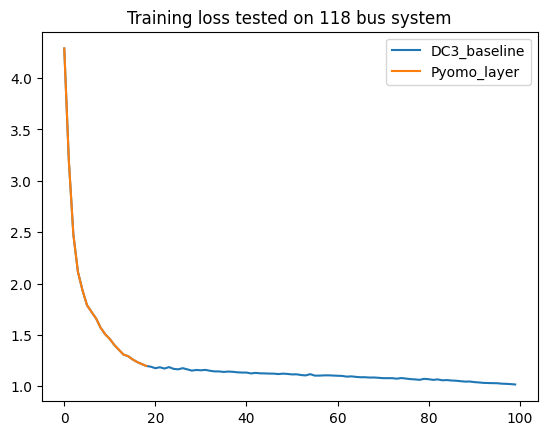

In [16]:
plt.plot(dc3, label = "DC3_baseline")
plt.plot(epoch_loss, label = "Pyomo_layer")

plt.legend()
plt.title("Training loss tested on 118 bus system")

In [41]:
np.save("epoch_loss_pyomolayer.npy", epoch_loss)

In [17]:
dc3 = np.load("epoch_loss.npy")

Text(0.5, 1.0, 'Training loss (Add Pg_ref lower bounds in the Pyomo)')

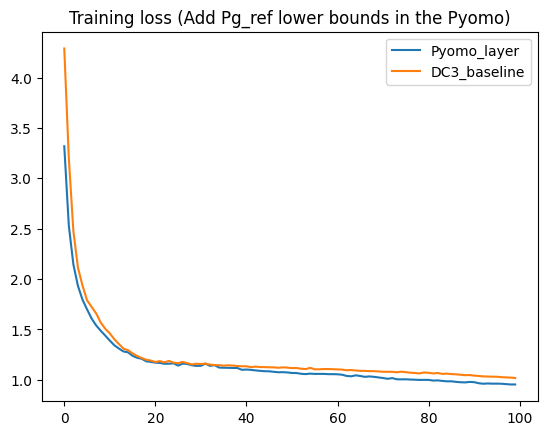

In [42]:
plt.plot(epoch_loss, label = "Pyomo_layer")
plt.plot(dc3, label = "DC3_baseline")
plt.legend()
plt.title("Training loss (Add Pg_ref lower bounds in the Pyomo)")

In [85]:
# start_time = time.time()
# for i in range(nepochs):
#     epoch_stats = {}
    
#     # Get train loss
#     solver_net.train()
 
#     for Xtrain, Ytrain in train_loader:

#         pg_train, _, vm_train, va_train = data.get_yvars(Ytrain)

#         solver_opt.zero_grad()

#         Yhat_train_partial = solver_net(Xtrain)

#         Yhat_train_partial_trans = data.complete_partial_tanh(Xtrain, Yhat_train_partial) #used to satisfy the voltage magnitude constraints
        
#         if i < 0:
#             pg, _, vm, _ = data.get_yvars(Ytrain)
#             Ytrain_partial = torch.cat((pg[:, data.pv_], vm[:, data.spv]), 1)
#             train_loss = torch.norm(Yhat_train_partial_trans -  Ytrain_partial)
#         else:
#             input = tuple([Yhat_train_partial_trans[:, :data.npv], Yhat_train_partial_trans[:, data.npv:], \
#                        Xtrain[:, :data.nbus], Xtrain[:, data.nbus:]])
        
#             primal_batch, _, _, _, _ = Layer(*input)

#             Yhat_train = torch.zeros(Xtrain.shape[0], data.ydim)
#             Yhat_train[:, data.pv_] = Yhat_train_partial_trans[:, :data.npv]
#             # vm 
#             Yhat_train[:, data.ng*2+data.pq] = primal_batch[:, :len(data.pq)]
#             Yhat_train[:, data.ng*2+data.spv] = Yhat_train_partial_trans[:, data.npv:]
#             # va
#             Yhat_train[:, data.ng*2+data.nbus+data.nonslack_idxes] = primal_batch[:, len(data.pq):len(data.pq) + len(data.nonslack_idxes)]
#             Yhat_train[:, data.ng*2+data.nbus+data.slack.item()] = slackva.item()
#             # pg_ref
#             Yhat_train_ = Yhat_train.clone()
#             res = data.eq_resid(Xtrain, Yhat_train_)
#             Yhat_train[:, data.slack_] = -res[:, data.pflow_start_eqidx + data.slack]
#             # qg
#             Yhat_train[:, data.ng:data.ng*2] = -res[:, data.qflow_start_eqidx + data.spv]
#             # calculate the branch flow
#             obj_cost = data.obj_fn(Yhat_train).mean()

#             unsupervised_loss = torch.norm(data.ineq_dist(Xtrain, Yhat_train), dim=1).mean()

#             train_loss = obj_weight * obj_cost + unsupervised_loss 

#         train_loss.backward()

#         solver_opt.step()

#         batch_loss.append(train_loss.detach().cpu().numpy())

#         # batch_loss_unsuper.append(unsupervised_loss.detach().cpu().numpy())
        
#     scheduler.step()
#         # Get valid loss
#     solver_net.eval()
#     with torch.no_grad():
#         for Xvalid, Yvalid in valid_loader:
            
#             Yhat_valid_partial = solver_net(Xvalid).detach()
#             Yhat_valid_partial_trans = data.complete_partial_tanh(Xvalid, Yhat_valid_partial)
#             Yhat_valid = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans)
        
#         eval_net(data, Xvalid, Yhat_valid, args, 'valid', epoch_stats)
        
#     print(
#         'Epoch {}: train loss {:.4f}, train unsup loss {:.4f}, eval {:.4f}, ineq max {:.8f}, ineq mean {:.8f}, ineq num viol {:.4f}'.format(
#             i, np.mean(batch_loss), np.mean(batch_loss_unsuper), np.mean(epoch_stats['valid_eval']), np.mean(epoch_stats['valid_ineq_max']),
#             np.mean(epoch_stats['valid_ineq_mean']), np.mean(epoch_stats['valid_ineq_num_viol_0'])))
    
#     epoch_loss.append(np.mean(batch_loss))
#     # epoch_loss_unsuper.append(np.mean(batch_loss_unsuper))
    
#     batch_loss = []
#     # batch_loss_unsuper = []
# #     savepath = os.path.join('data/super/DC3/3Layers/hidden_dim50/obj01_LR0005.pth')
# #    torch.save(solver_net.state_dict(), savepath)    
# train_time = time.time() - start_time
# print(train_time)

In [87]:
solver_net.eval()

test_dataset = TensorDataset(data.testX, data.testY)

test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

with torch.no_grad():
    for Xtest, Ytest in test_loader:

        Xtest = Xtest
        Ytest = Ytest

        Yhat_test_partial = solver_net(Xtest)

        Yhat_test_partial_trans = data.complete_partial_tanh(Xtest, Yhat_test_partial) #used to satisfy the voltage magnitude constraints

        Yhat_test = PFFunction_eval(data)(Xtest, Yhat_test_partial_trans)
    

In [88]:
pg_test, qg_test, vm_test, va_test = data.get_yvars(Yhat_test)

In [89]:
print(torch.mean(data.obj_fn(Yhat_test)))
print(torch.mean(data.obj_fn(data.testY)))
gap = 100 * torch.abs(torch.mean(data.obj_fn(Yhat_test)) - torch.mean(data.obj_fn(data.testY))) / torch.mean(data.obj_fn(data.testY))
print(gap)

tensor(9.5838)
tensor(10.0867)
tensor(4.9859)


In [90]:
print(torch.mean(torch.mean(data.ineq_dist(Xtest, Yhat_test), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest, Yhat_test), dim=1)[0]))
print(np.mean(torch.sum(data.ineq_dist(Xtest, Yhat_test) > 0, dim=1).detach().numpy()))
print(100*(1 - np.mean(torch.sum(data.ineq_dist(Xtest, Yhat_test) > 0, dim=1).detach().numpy())/torch.sum(data.ineq_dist(Xtest, Yhat_test) > 0, dim=0).shape[0]))

tensor(4.7393e-06)
tensor(0.0021)
0.2
99.95575221238938


In [91]:
# check the VM violation
print(vm_test.shape)
lower_correct = (vm_test >= data.vmin)
upper_correct = (vm_test <= data.vmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(high_violation_ratio)

torch.Size([20, 118])
torch.Size([20, 118])
0.0
0.0


In [95]:
# check the Pg violation
print(pg_test.shape)
lower_correct = (pg_test >= data.pmin)
upper_correct = (pg_test <= data.pmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

torch.Size([20, 54])
torch.Size([20, 54])
0.0
0.0


In [96]:
# check the Qg violation
print(qg_test.shape)
lower_correct = (qg_test >= data.qmin)
upper_correct = (qg_test <= data.qmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

torch.Size([20, 54])
torch.Size([20, 54])
0.0
0.0037037037037036535


In [94]:
#equality 
equality_mismatch = data.eq_resid(Xtest, Yhat_test).detach()

print(torch.mean(torch.abs(equality_mismatch)))

print(torch.mean(torch.norm(equality_mismatch, dim=1)))


tensor(8.9282e-08)
tensor(3.4523e-06)
